In [13]:
!pip install scikit-learn-extra

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids

In [21]:
df = pd.read_csv("store_customers.csv")

print(df.head())
print(df.isnull().sum())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0
CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


In [22]:
df = df.dropna()

In [23]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [24]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
kmedoids = KMedoids(n_clusters=3, random_state=42)
kmedoids.fit(X_scaled)


KMedoids(n_clusters=3, random_state=42)

In [34]:
print("Medoid Indexes:")
print(kmedoids.medoid_indices_)

print("Medoid Points:")
print(X.iloc[kmedoids.medoid_indices_])

Medoid Indexes:
[341 912 186]
Medoid Points:
      Age  Annual Income (k$)  Spending Score (1-100)
348  29.0                32.2                    59.0
929  53.0                97.0                    18.0
192  37.0                52.6                    46.0


In [31]:
labels = kmedoids.labels_
print(labels)

[2 2 2 1 0 0 1 2 2 2 0 0 2 0 0 0 0 2 0 0 1 2 2 0 0 2 2 0 2 0 1 2 0 2 0 2 0
 0 2 1 2 2 0 0 0 0 2 2 0 2 0 0 2 2 2 0 0 2 2 0 2 0 0 2 1 0 2 0 2 1 0 1 0 2
 2 2 0 0 2 2 1 0 2 0 1 2 0 2 2 2 0 0 2 0 2 0 2 0 0 0 0 2 2 1 2 2 0 0 2 2 1
 0 2 2 2 2 1 0 2 0 2 1 0 0 2 0 0 2 0 2 1 0 2 2 0 2 1 0 2 0 2 0 2 2 2 2 2 0
 2 2 0 1 2 0 1 0 2 2 0 1 2 2 1 0 0 0 0 2 2 0 2 0 1 0 1 2 0 0 0 0 1 2 0 0 2
 1 2 0 2 2 0 0 2 0 0 2 1 1 0 0 2 0 2 1 2 1 2 2 2 1 0 0 2 0 1 0 2 0 0 1 0 0
 0 2 0 2 0 0 1 2 0 0 0 2 2 0 2 1 0 2 0 0 2 2 0 2 1 2 0 0 2 0 0 1 0 0 0 0 2
 0 1 0 0 0 2 0 2 0 2 2 2 0 2 0 2 2 1 0 1 2 2 2 2 0 0 2 2 2 0 2 2 2 2 0 0 2
 2 0 2 1 0 2 0 0 1 2 2 1 2 2 2 2 2 2 2 0 1 0 0 2 2 2 2 0 0 2 0 1 2 0 0 2 0
 0 0 2 0 0 2 0 0 0 0 2 1 2 0 2 0 0 0 2 0 2 1 2 2 2 2 2 2 2 2 2 2 1 2 1 0 1
 2 1 0 0 0 0 0 0 2 2 2 1 2 2 0 1 1 2 0 1 2 2 0 0 2 2 2 1 0 2 2 2 2 0 0 2 2
 0 1 2 2 2 1 1 2 2 2 1 0 2 1 0 0 2 2 2 2 1 0 0 0 2 0 0 2 0 2 2 0 0 0 0 2 0
 2 0 0 2 0 0 0 1 2 0 0 2 2 1 1 2 0 2 0 0 1 1 0 2 2 1 2 2 2 0 2 0 0 0 0 1 2
 2 1 2 0 1 2 0 0 0 0 2 1 

In [32]:
df["Cluster"] = labels
print(df.head())

   CustomerID  Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000       1  39.0                59.9                    58.0   
1        1001       1  34.0                48.4                    37.0   
2        1002       0  40.0                70.5                    26.0   
3        1003       0  47.0                81.1                    30.0   
4        1004       0  33.0                42.1                    58.0   

   Cluster  
0        2  
1        2  
2        2  
3        1  
4        0  


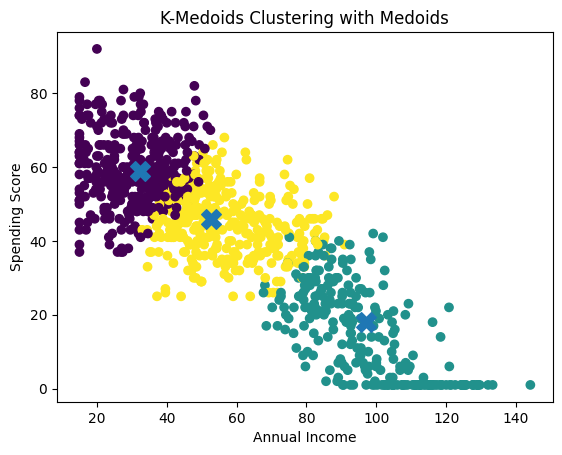

In [35]:
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=labels)

medoids = X.iloc[kmedoids.medoid_indices_]
plt.scatter(medoids["Annual Income (k$)"], medoids["Spending Score (1-100)"],
            marker='X', s=200)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Medoids Clustering with Medoids")
plt.show()